<a href="https://colab.research.google.com/github/tovagabrielsson-arch/cb2330-project/blob/main/ob_ln_microbiota.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Gut Microbiota from Twins Discordant for Obesity Modulate Metabolism in Mice**

#Project Card

##The Paper
The paper reports a study on four adult female twin pairs, where one is lean, and the other obese. Microbiota from each twin was transplanted into adult germ-free mice. The study monitored the changes in fat mass and body composition in mice. Furthermore, the study examined the effects of diet, as well as cohousing mice that received discordant microbiota.

The study found that mice receiving microbiota from an obese twin gained more fat mass than mice that received microbiota from a lean twin.

However, cohousing mice with lean and obese microbiota could prevent the increase in fat mass in the mice with obese microbiota, when their microbiota was transformed to the microbia's metabolic profile similar to the lean mice. This effect was only observed in mice receiving a diet representing the healthiest tertile in the U.S.      


####Notes on the method
The microbiota was profiled using 16S ribosomal RNA profiling, shotgun sequencing, RNA sequencing and mass spectrometry.
Body mass was determined using quantitative magnetic resonance.



##The Data Object

Measurements of percentage change in fat mass in mice colonized with gut microbiota from either the lean or obese member of a discordant twin pair. The values used in our model were approximated manually from Figure 1E of the paper at days 8, 15, 22, 29 and 35.

##The Random Variable Chosen
We chose the increase in fat mass after 15 days as our random variable.
This increase is measured in percentage points of change since day 0.

##What the Paper Does
The paper presents the percent change in fat mass and body composition in figures, showing only the mean with error bars for obese and lean mice. There is also a figure showing the % change in fat mass for one of the twin pairs for five timepoints from day 8 to day 35. They report that according to a two-way ANOVA, there was a significant difference in fat mass (defined as p < 0.05) between mice recieving lean vs obese microbiota.

The paper also reports on the specific bacteria found in each of the mice's microbiota, as well as how the bacterial cultures changed after cohousing, and with different diets.

##The Generative Model
We model fat mass change as the accumulation of daily changes. Each mouse experiences a random daily fluctuation with normal distribution.

For mice colonized with microbiota from a lean twin, the change per day is simply the normally distributed variable. For the mice colonized with microbiota from an obese twin, the change per day is the normally distributed variable, plus the additional variable theta.


##Parameters and Assumptions
####Our key parameters are:

**Sigma**: The standard deviation of the random daily change in fat mass. Measured in percentage points per day. We set this parameter to 0.5. Increasing sigma increases the spread of the data, but not the mean.

**Theta**: The extra daily fat mass gain that the mice get due to the obese microbiota. This was chosen from the figure in the paper, as 10/15 percentage points per day. Increasing theta increases the separation between the groups.

**V0**: This parameter was chosen as 0.0 percentage points per day to represent the baseline of average weight gain per day for lean mice being 0%.


####The Assumptions:
**Constant weight gain**: We assume that the weight gain effect from the introduced microbiota is constant over time

**Same variability**: The same sigma was used for both groups, assuming that the variability is the same within each group.

**Biological noise and other factors**: We assume that all of the other factors affecting gain of fat mass is included in our random noise parameter.

**Separate housing and neutral diet**: For this model, we decided to ignore the effect of cohousing and diet, assuming that the mice are housed separately and getting the standard diet of low fat mouse chow.


##The Forward Simulation
We simulate 1000 hypothetical mice per group to visualize the probability distribution implied by the model. This simulation is based on the assumption that obese mice's change in fat mass per day is on average 10/15 percentage points more than lean mice. We model the change in fat mass per day over 15 days, measured in percentage points.


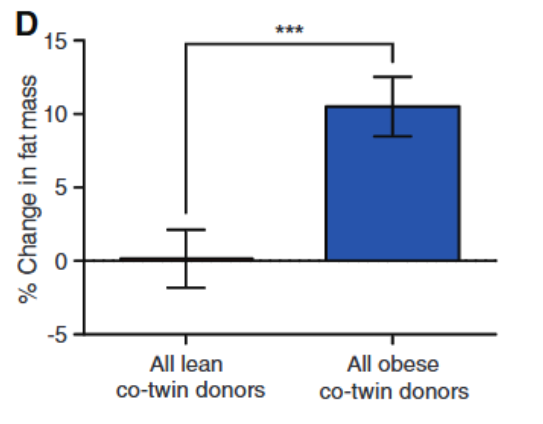

##The Parameterization
We estimated theta using data from figure 1E in the paper. This figure follows the change in fat mass in one twin pair from day 8 to day 35.

We use grid search to find the average percentage change in fat mass for obese mice compared to lean mice over 15 days.

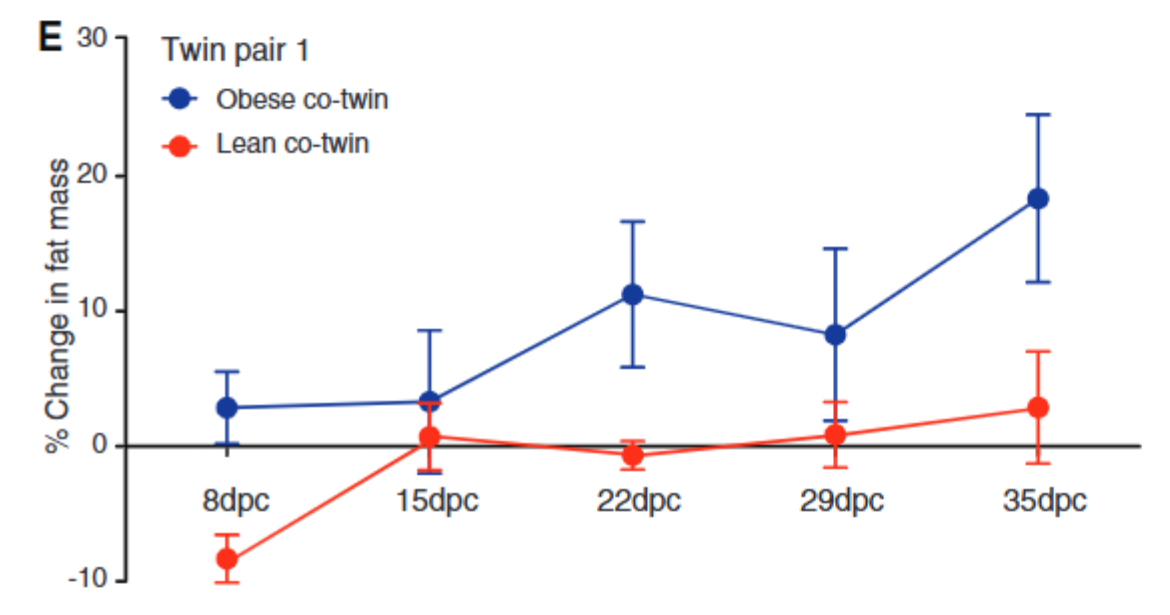

##What the model adds to the paper
- Our model adds a quantitative parameter, theta, describing the differences between the groups. The paper visualizes this effect in figures and writing, but not quantitatively.

- The paper follows 4 mice per twin pair, and 4 twin pairs. This makes the a total 16 mice per group, while our model simulated this effect for 1 000 mice per group. However, all of the data is based on the small dataset from the paper.

- The model fit and bootstrap clearly show how uncertain the overall effect is due to the small amount of data.

##Model Limitations
Our model is limited to only reflect the difference in fat mass directly due to microbiota.

The model is very simplified. Our initial forward simulation is based on our assumption of the extra daily fat mass gain being 10/15 percentage points per day for mice recieving microbiota from the obese twin compared to mice recieving microbiota from the lean twin. The value of 10/15 is based on the average weight change after 15 days being 10% for obese mice compared to 0% for lean mice.

Due to the limited data in the paper, the grid search method is based on a very small set of 5 datapoints per type of microbiota. The datapoints were visually estimated from the figure and only represents the weight fluctuations of mice recieving microbiota one twin pair over days 8 to 35. This means that the average weight gain per day is only based data from 4 mice per group, all with the same donor.  


Note that we refer to the mice as "lean" and "obese" in the code, and ln-mice and ob-mice in the text. The correct interpretation of this should be "the germ-free mice in which microbiota was transplanted from the lean/obese twin". It has been shortened for convenience.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bootstrap
import pandas as pd
from pathlib import Path

# Forward simulation

####Parameters


In [19]:
mice = 1000 #This is the number of mice that we simulate in each group
day = 15 #This is for how long we are running this simulation -> 15 day
v0 = 0.0 #This is our baseline. The report showed that the lean mice on average had a fat mass change of 0% -> therefore it is our starting value
theta = 10/15 #This is the extra daily fat mass gain that the mice get due to the obese microbiota. According to the figure the obese mice gained about 10 percentage points more after 15 days which gives 10/15 per day
sigma = 0.5 #This is added to give some sort of randomness between mice because they don't all react (gain weight equally fast or slow) the same way


####Empty lists
We append and store the final fat mass changes for the Ln and Ob mice respectively

In [20]:
lean = [] #Here we create an empty list to which we will append and store the final fat mass changes for the ln-mice
obese = [] #Here we create an empty list to which we will append and store the final fat mass changes for the ob-mice

####Loops to simulate changes in fat mass
We created a loop for ln-mice and ob-mice separately. The functions loop over our 1 000 mice and our 15 days, assuming normal distribution with the mean 0 and standard deviation 0.5. The loop then adds these values to the lists created above.

In [21]:
#Looping over the number of mice and the number of days. Appending values, one per mouse, to the list,
for i in range(mice):
  fat = 0
  for j in range(day):
    fat = fat + v0 + np.random.normal(0, sigma)
  lean.append(fat)

for i in range(mice):
  fat = 0
  for j in range(day):
    fat = fat + (v0 + theta) + np.random.normal(0, sigma)
  obese.append(fat)

In [22]:
# Print the list representing the final percentage fat mass change after 15 days for each mouse
print(f"lean: {lean}")
print(f"obese: {obese}")

lean: [0.2989687838631381, -3.852087493874153, 1.0928673648390927, -0.08808533236334015, -0.9152116010087942, 1.7668383371976133, 1.0491679855662455, 2.1160735857396045, -2.299820112060176, -0.8697446599380836, 0.7868088974471583, 2.7141021503471006, 1.674657453381481, 1.7268737182967888, -2.1097887202113617, 1.0874309106452862, 1.7821671560040624, -3.422309133605394, 3.0732474288183043, -0.7678471015356358, -3.4889229698622, 1.36911109997274, 0.9594045367724089, 0.39460896348043367, -0.7257446520000423, 0.3465886196251461, -0.6869867420701048, -3.968025046453234, -3.0668226723885916, 0.2595224470998348, -2.0010182895030377, -1.9911116168803136, -2.7408695432706986, -0.7770829178959338, -1.1881757444831988, -2.193512422444554, -1.4145114523973967, -2.4311115704096715, 2.2627938613052017, 0.8666968541784374, -0.7637495606202211, 1.5720658131536416, -1.0633921458641722, -0.7181406511740259, -0.5260822458434533, 0.24154033010234982, 1.028486148233911, 0.22665417072952143, -2.9887881093875

In [23]:
#Calculating the average percentage fat mass change
mean_lean_mice = np.mean(lean)
mean_obese_mice = np.mean(obese)

print(f"Mean ln: {mean_lean_mice}")
print(f"mean ob: {mean_obese_mice}")

Mean ln: -0.08302422464599894
mean ob: 9.985970560835765


In [24]:
# Calculating the standard deviation
std_lean_mice = np.std(lean)
std_obese_mice = np.std(obese)

print(f"std ln: {std_lean_mice}")
print(f"std ob: {std_obese_mice}")

std ln: 1.9480943960300838
std ob: 1.9401217808520719


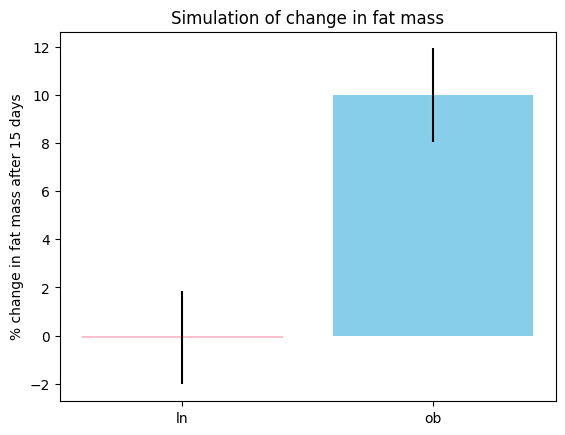

In [25]:
# Plotting the average percentage fat mass change, with our standard deviation error bars
# Similar to the papers Figure D
mice_groups = ["ln", "ob"]
standard_deviations = [std_lean_mice, std_obese_mice]
mice_means = [mean_lean_mice, mean_obese_mice]
plt.bar(mice_groups, mice_means, yerr=standard_deviations, color= ["pink","skyblue"])
plt.ylabel("% change in fat mass after 15 days")
plt.title("Simulation of change in fat mass")
plt.show()

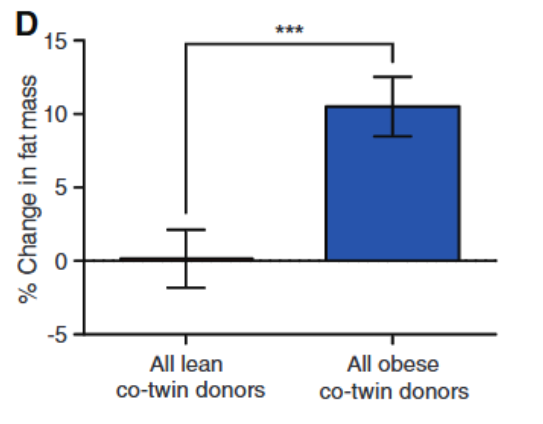

# Backward simulation

In [26]:
# Reading the data from our csv file

local_path = Path("datafile/data.csv")

if local_path.exists():
    data = pd.read_csv(local_path)
else:
    url = "https://raw.githubusercontent.com/tovagabrielsson-arch/cb2330-project/main/datafile/data.csv"
    data = pd.read_csv(url)

days_report = data["day"].to_numpy()
lean_report = data["lean"].to_numpy()
obese_report = data["obese"].to_numpy()

####Least Squares/Grid Search
 Assuming the adiposity changes with a fixed parameter theta.
We loop through the values extracted from the plot, to find the best "theta". Grid search to find the best theta, and least squares to evaluate each theta.



In [27]:
# Starting with the obese group

# Setting start values for the "best theta" we want to find, the smallest error and a list to save the errors
# Starting with a large value for smallest error, so any error will be smaller than this
best_theta_ob = 0
smallest_error_ob = 10000
errors_ob = []

# Testing 1 000 values for theta, ranging from 0 and 1.5.
# Looping over the values in our data, calculating predicted values and saving the error for each and saving
# Saving the values (error and theta) for theta that gives a smaller error than the previously lowest error
for theta in np.linspace(0, 1.5, 1000):
  error = 0
  for i in range(len(days_report)):
    predicted_value = theta * days_report[i]
    error = error + (obese_report[i] - predicted_value)**2
  errors_ob.append(error)
  if error < smallest_error_ob:
    smallest_error_ob = error
    best_theta_ob = theta

print("Best theta:", best_theta_ob)
print("SSE:", smallest_error_ob)

Best theta: 0.41291291291291293
SSE: 42.3474983993002


In [28]:
#The same thing, but for the lean group

# Setting start values for the "best theta" we want to find, the smallest error and a list to save the errors
# Starting with a large value for smallest error, so any error will be smaller than this
best_theta_ln = 0
smallest_error_ln = 10000
errors_ln = []

# Testing 1 000 values for theta, ranging from 0 and 1.5.
# Looping over the values in our data, calculating predicted values and saving the error for each and saving
# Saving the values (error and theta) for theta that gives a smaller error than the previously lowest error
for theta in np.linspace(0, 1.5, 1000):
  error = 0
  for i in range(len(days_report)):
    predicted_value = theta * days_report[i]
    error = error + (lean_report[i] - predicted_value)**2
  errors_ln.append(error)
  if error < smallest_error_ln:
    smallest_error_ln = error
    best_theta_ln = theta

print("Best theta:", best_theta_ln)
print("SSE:", smallest_error_ln)

Best theta: 0.01951951951951952
SSE: 91.93454490526561


In [29]:
theta_final = best_theta_ob - best_theta_ln

print ("The extra weight gain due to obese microbiota", theta_final)

after_days = theta_final * 15
print ("The average weight gain after 15 days", after_days)

The extra weight gain due to obese microbiota 0.3933933933933934
The average weight gain after 15 days 5.9009009009009015


####Interpretation
According to our model, the change in fat mass is 0.413 percentage points per day for the ob-mice, with a sum of squared errors at about 42.35.

For the ln-mice, the change in fat mass is 0.020 percentage points per day, with a sum of squared errors of 91.93.

The difference is our final theta value: 0.393 percentage points per day, or about 5.90% after 15 days.

This can indicate that our first approximation of theta, obtained from Figure 1D to 0.6667, was a bit too high. However, we expected the values to differ, since they are based on different data.

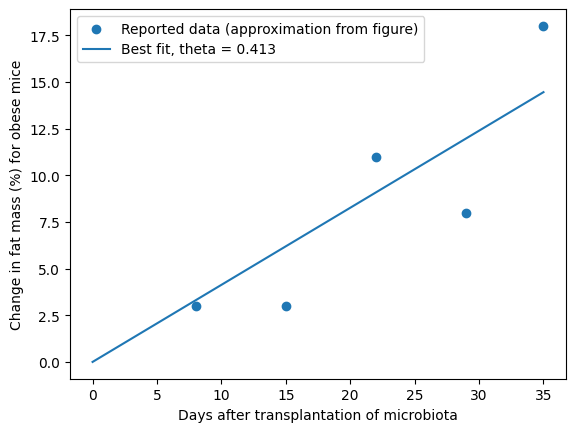

In [30]:
#Here we plot the models best theta for obese mice compared to the reported data
t_plot = np.linspace(0, 35, 200)
model_plot = best_theta_ob * t_plot

plt.scatter(days_report, obese_report, label="Reported data (approximation from figure)")
plt.plot(t_plot, model_plot, label=f"Best fit, theta = {best_theta_ob:.3f}")

plt.xlabel("Days after transplantation of microbiota")
plt.ylabel("Change in fat mass (%) for obese mice")
plt.legend()
plt.show()

As we can see, the model does not fit super well.

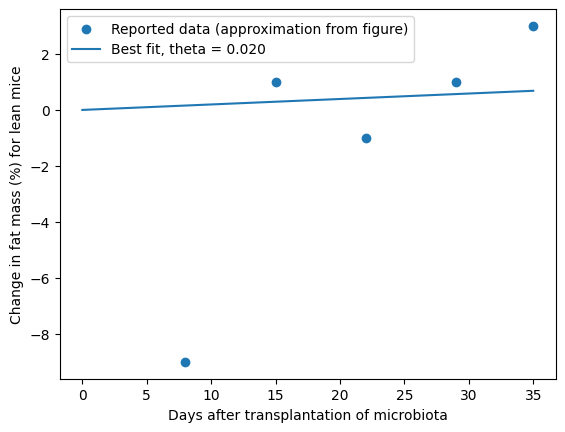

In [31]:
#The same plot, but for lean mice
t_plot = np.linspace(0, 35, 200)
model_plot = best_theta_ln * t_plot

plt.scatter(days_report, lean_report, label="Reported data (approximation from figure)")
plt.plot(t_plot, model_plot, label=f"Best fit, theta = {best_theta_ln:.3f}")

plt.xlabel("Days after transplantation of microbiota")
plt.ylabel("Change in fat mass (%) for lean mice")
plt.legend()
plt.show()

The model fits even worse for the lean mice.

#### Bootstrap

Best estimate of Theta_Ob = 0.41291291291291293
95% CI = [0.260747   0.50775416]


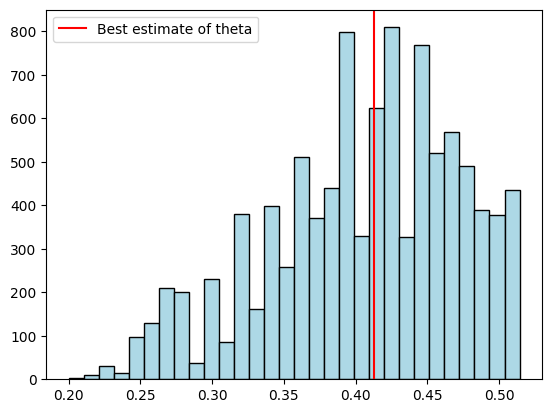

In [32]:
# Reading in the data, and converting it to arrays
days_report = data["day"].to_numpy()
obese_report = data["obese"].to_numpy()
lean_report = data["lean"].to_numpy()

# A loop repeating bootstrap 10 000 times. Choosing random indexes in our range (0 to 5), with replacement.
theta_boot = []
for i in range(10000):
    idx = np.random.choice(len(days_report), size=len(days_report),replace=True)
    x = days_report[idx]
    y = obese_report[idx]

    theta = np.sum(x * y) / np.sum(x**2)
    theta_boot.append(theta) #This is the least-squares estimate of theta with the bootstrap sample

print("Best estimate of Theta_Ob =", best_theta_ob)
print("95% CI =", np.percentile(theta_boot, [2.5, 97.5]))

plt.hist(theta_boot, color = 'lightblue', bins=30, edgecolor = 'black')
plt.axvline(best_theta_ob, color='red', label='Best estimate of theta')
plt.legend()
plt.show()

#### Interpretation of bootstrap

The red line is our best estimated theta_Ob at 0.413 found with grid search. The diagram shows 10 000 estimated theta values with bootstrap resampling. The bars represent how often that theta value in that range showed up which will change with each run of the above cell.

The 95% bootstrap percentile interval describes the variation in fitted theta obtained by repeatedly resampling our five digitized time points.  The interval is pretty large which could be largely based on the fact that we only had 5 data points to work with.

Best estimate of Theta_Ln = 0.01951951951951952
95% CI = [-0.13777192  0.07190591]


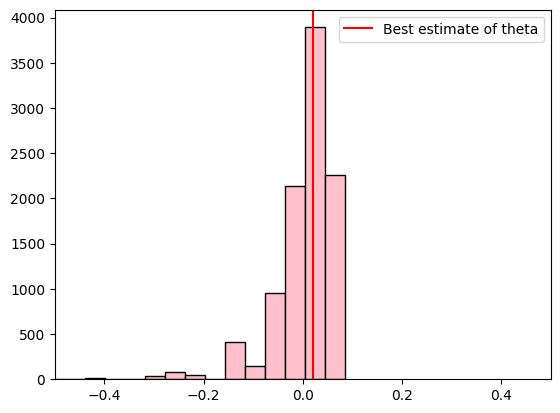

In [33]:
# A loop repeating bootstrap 10 000 times. Choosing random indexes in our range (0 to 5), with replacement.
theta_boot = []
for i in range(10000):
    idx = np.random.choice(len(days_report), size=len(days_report),replace=True)
    x = days_report[idx]
    y = lean_report[idx]

    theta = np.sum(x * y) / np.sum(x**2)
    theta_boot.append(theta) #This is the least-squares estimate of theta with the bootstrap sample

print("Best estimate of Theta_Ln =", best_theta_ln)
print("95% CI =", np.percentile(theta_boot, [2.5, 97.5]))

plt.hist(theta_boot, color = 'pink', bins=30, edgecolor = 'black')
plt.axvline(best_theta_ln, color='red', label='Best estimate of theta')
plt.xlim(-0.5, 0.5)
plt.legend()
plt.show()

#### Interpretation of bootstrap

The red line is our best estimated theta_Ln at 0.02 found with grid search. The diagram shows 10 000 estimated theta values with bootstrap resampling. The bars represent how often that theta value in that range showed up which will change with each run of the above cell.

We can see that the data is centered around zero which is not suprising since all of the recorded data was close to zero.